#Code with the topic: Gradient_Boosting_Regression

#Objective:

#The goal is to understand how the code is structured and which #libraries are used to create a model like this

#Technologies:

#Pandas
#Python
#Jupyter notebook
#Visual Studio Code

#method used:

Gradient Boosting Regressor

#What makes Gradient Boosting different?

#The central idea is:

#Each new tree learns solely from the mistakes made by the #previous trees.

In [13]:
#We import the libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
data = pd.read_csv("Gradient_Boosting_Regressionn.csv")

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   squaremeters  8 non-null      int64
 1   rooms         8 non-null      int64
 2   age           8 non-null      int64
 3   price         8 non-null      int64
dtypes: int64(4)
memory usage: 388.0 bytes


In [16]:
data.describe()

,squaremeters,rooms,age,price
count,8.000000,8.000000,8.000000,8.000000
mean,122.500000,3.250000,6.500000,262500.000000
std,38.452197,1.035098,4.566962,93465.043122
min,80.000000,2.000000,1.000000,150000.000000
25%,97.500000,2.750000,3.500000,210000.000000
50%,115.000000,3.000000,6.000000,245000.000000
75%,135.000000,4.000000,8.500000,297500.000000
max,200.000000,5.000000,15.000000,450000.000000


In [17]:
data.head()

,squaremeters,rooms,age,price
0,80,2,10,150000
1,100,3,5,220000
2,120,3,8,250000
3,150,4,2,320000
4,90,2,15,180000


In [18]:
data.columns

Index(['squaremeters', 'rooms', 'age', 'price'], dtype='object')

In [ ]:
#We separate X and Y

X = data[["squaremeters","rooms","age"]]
Y = data["price"]

In [ ]:
# Split the dataset into training and testing sets

x_train,x_test,y_train,y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [ ]:
#We create the model

model= GradientBoostingRegressor(

    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Standard hyperparameters that provide a good balance
# between accuracy and overfitting.

In [ ]:
#Training

model.fit(x_train,y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [23]:
#Predictions

predictions= model.predict(x_test)

In [ ]:
#Evaluate

mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

In [ ]:
print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

In [ ]:
#Prediction of a New Home

new_house = pd.DataFrame({
    "squaremeters":[140],
    "rooms":[4],
    "age":[3]
})

estimated_price= model.predict(new_house)

print(f"Estimated price ${estimated_price[0]:,.2f}")



Precio estimado $305,229.95


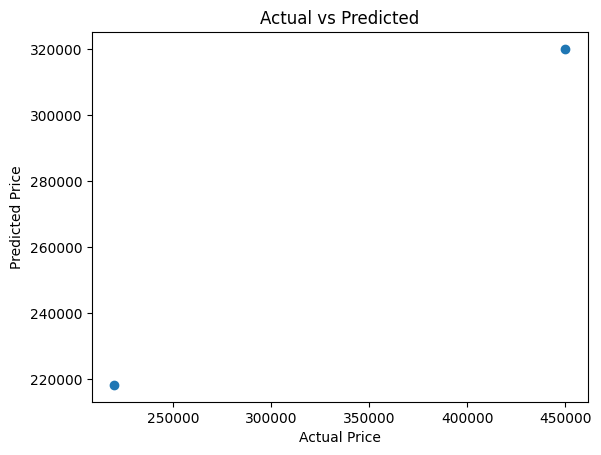

In [30]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()